<a href="https://colab.research.google.com/github/msatyasambhav-beep/Machine-Learning/blob/main/PR_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures,StandardScaler

In [7]:
X = 6 * np.random.rand(200,1)-3
y = 0.8*X**2 + 0.9*X + 2 + np.random.randn(200,1)

#y=2 + 0.9X+0.8^2+noise

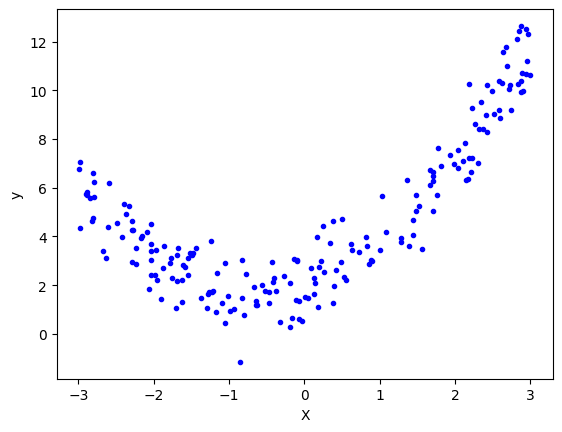

In [9]:
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [10]:
#Train Test Split

X_train,X_test,y_train,y_test,=train_test_split(X,y,test_size=0.2,random_state=3)

In [11]:
#Applying the Linear Regression Model

lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(X_test)
r2_score_lr = r2_score(y_test,y_pred)
print("R2-score is:",r2_score_lr)

R2-score is: 0.41968886898755287


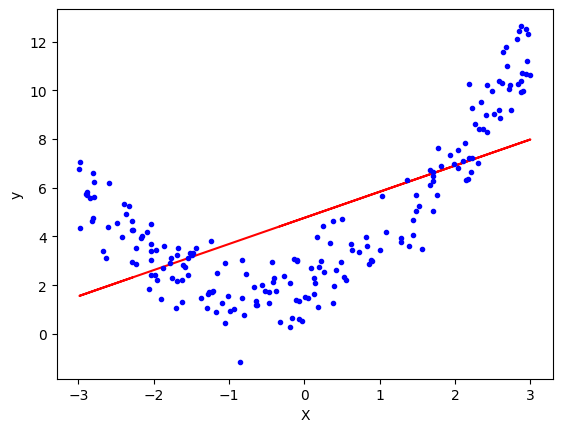

In [15]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

###Applying Polynomial Linear Regression

In [16]:
poly = PolynomialFeatures(degree=2,include_bias=True)

X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.transform(X_test)

In [22]:
print(X_train[0])

[-0.32358557]


In [18]:
print(X_train_trans[0])

[ 1.         -0.32358557  0.10470762]


In [23]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [24]:
y_pred = lr.predict(X_test_trans)

In [26]:
r2_score(y_test,y_pred)

0.894598652369254

In [27]:
print(lr.coef_)

[[0.         0.96424332 0.7529783 ]]


In [28]:
print(lr.intercept_)

[2.1030757]


In [30]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

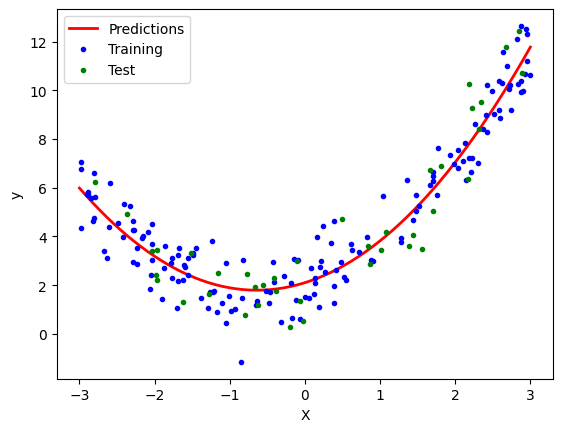

In [39]:
plt.plot(X_new,y_new,"r-",linewidth=2,label='Predictions')
plt.plot(X_train,y_train,"b.",label='Training')
plt.plot(X_test,y_test,"g.",label='Test')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [40]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

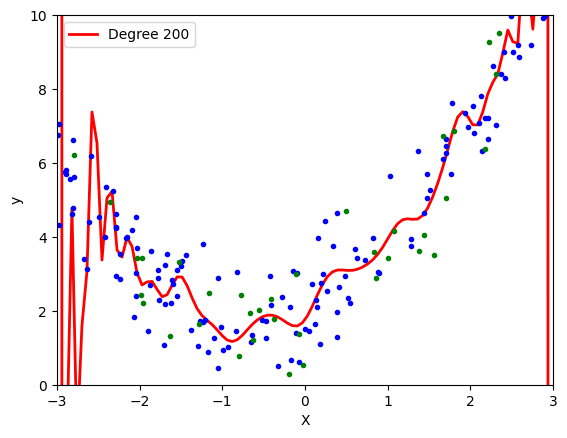

In [46]:
polynomial_regression(degree=200)

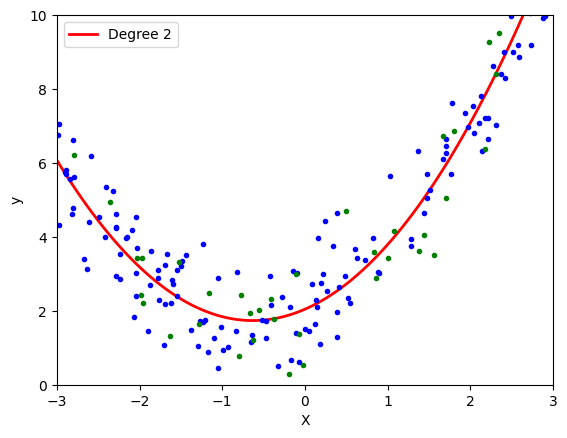

In [49]:
polynomial_regression(degree=2)

In [47]:
poly.powers_


array([[0],
       [1],
       [2]])

####Visualize the data using 3-d plot

In [52]:
#3D polynomial regression
x = 7*np.random.rand(100,1)-2.8
y = 7*np.random.rand(100,1)-2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.18*x*y + 2+ np.random.rand(100,1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy +2

In [55]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()